In [1]:
print("Healthcare Data Pipeline Project Started Successfully")

Healthcare Data Pipeline Project Started Successfully


In [2]:
import pandas as pd
import numpy as np
import os

In [3]:
os.makedirs("bronze", exist_ok=True)
os.makedirs("silver", exist_ok=True)
os.makedirs("gold", exist_ok=True)

print("Project folders created successfully.")

Project folders created successfully.


In [4]:
df = pd.read_csv("patients_records.csv")

print("Dataset loaded successfully.")

Dataset loaded successfully.


In [5]:
print("Number of Rows :", df.shape[0])
print("Number of Columns :", df.shape[1])

Number of Rows : 55500
Number of Columns : 15


In [6]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55500 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                55500 non-null  object 
 1   Age                 55500 non-null  int64  
 2   Gender              55500 non-null  object 
 3   Blood Type          55500 non-null  object 
 4   Medical Condition   55500 non-null  object 
 5   Date of Admission   55500 non-null  object 
 6   Doctor              55500 non-null  object 
 7   Hospital            55500 non-null  object 
 8   Insurance Provider  55500 non-null  object 
 9   Billing Amount      55500 non-null  float64
 10  Room Number         55500 non-null  int64  
 11  Admission Type      55500 non-null  object 
 12  Discharge Date      55500 non-null  object 
 13  Medication          55500 non-null  object 
 14  Test Results        55500 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.4

In [8]:
df.isnull().sum()

,0
Name,0
Age,0
Gender,0
Blood Type,0
Medical Condition,0
Date of Admission,0
Doctor,0
Hospital,0
Insurance Provider,0
Billing Amount,0


In [9]:
# Create Bronze Layer

bronze_df = df.copy()

print("Bronze layer created successfully.")

Bronze layer created successfully.


Bronze Layer

In this step, the original healthcare dataset is stored without making any modifications. This layer keeps the raw data unchanged so it can be used later for validation and reference during the data pipeline process.

In [10]:
bronze_df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [11]:
print("Rows:", bronze_df.shape[0])
print("Columns:", bronze_df.shape[1])

Rows: 55500
Columns: 15


In [12]:
bronze_df.to_csv("bronze/bronze_data.csv", index=False)

print("Bronze data saved successfully.")

Bronze data saved successfully.


In [13]:
import os

print(os.listdir("bronze"))

['bronze_data.csv']


In [14]:
# Create Silver Layer

silver_df = bronze_df.copy()

print("Silver layer created successfully.")

Silver layer created successfully.


In [15]:
duplicate_count = silver_df.duplicated().sum()

print("Duplicate Records :", duplicate_count)

Duplicate Records : 534


In [16]:
silver_df = silver_df.drop_duplicates()

print("Duplicates removed successfully.")

Duplicates removed successfully.


In [17]:
silver_df.isnull().sum()

,0
Name,0
Age,0
Gender,0
Blood Type,0
Medical Condition,0
Date of Admission,0
Doctor,0
Hospital,0
Insurance Provider,0
Billing Amount,0


In [18]:
silver_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54966 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Name                54966 non-null  object 
 1   Age                 54966 non-null  int64  
 2   Gender              54966 non-null  object 
 3   Blood Type          54966 non-null  object 
 4   Medical Condition   54966 non-null  object 
 5   Date of Admission   54966 non-null  object 
 6   Doctor              54966 non-null  object 
 7   Hospital            54966 non-null  object 
 8   Insurance Provider  54966 non-null  object 
 9   Billing Amount      54966 non-null  float64
 10  Room Number         54966 non-null  int64  
 11  Admission Type      54966 non-null  object 
 12  Discharge Date      54966 non-null  object 
 13  Medication          54966 non-null  object 
 14  Test Results        54966 non-null  object 
dtypes: float64(1), int64(2), object(12)
memory usage: 6.7+ MB


In [19]:
# Convert date columns into datetime format

silver_df["Date of Admission"] = pd.to_datetime(silver_df["Date of Admission"])
silver_df["Discharge Date"] = pd.to_datetime(silver_df["Discharge Date"])

print("Date columns converted successfully.")

Date columns converted successfully.


In [20]:
silver_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 54966 entries, 0 to 55499
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Name                54966 non-null  object        
 1   Age                 54966 non-null  int64         
 2   Gender              54966 non-null  object        
 3   Blood Type          54966 non-null  object        
 4   Medical Condition   54966 non-null  object        
 5   Date of Admission   54966 non-null  datetime64[ns]
 6   Doctor              54966 non-null  object        
 7   Hospital            54966 non-null  object        
 8   Insurance Provider  54966 non-null  object        
 9   Billing Amount      54966 non-null  float64       
 10  Room Number         54966 non-null  int64         
 11  Admission Type      54966 non-null  object        
 12  Discharge Date      54966 non-null  datetime64[ns]
 13  Medication          54966 non-null  object        


In [21]:
text_columns = [
    "Name",
    "Doctor",
    "Hospital",
    "Medical Condition",
    "Medication",
    "Insurance Provider"
]

for col in text_columns:
    silver_df[col] = silver_df[col].str.title()

print("Text formatting standardized successfully.")

Text formatting standardized successfully.


In [22]:
silver_df.columns = [
    "name",
    "age",
    "gender",
    "blood_type",
    "medical_condition",
    "date_of_admission",
    "doctor",
    "hospital",
    "insurance_provider",
    "billing_amount",
    "room_number",
    "admission_type",
    "discharge_date",
    "medication",
    "test_results"
]

print("Column names renamed successfully.")

Column names renamed successfully.


In [23]:
silver_df.head()

,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons And Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook Plc,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers And Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [24]:
silver_df.to_csv("silver/silver_data.csv", index=False)

print("Silver layer saved successfully.")

Silver layer saved successfully.


In [25]:
import os

print(os.listdir("silver"))

['silver_data.csv']


## Silver Layer

In this layer, duplicate records were removed and the dataset was standardized for further analysis. Date columns were converted into datetime format, important text fields were formatted consistently, and column names were renamed using snake_case. The cleaned dataset was then stored for the Gold layer.

In [26]:
# Create Gold Layer

gold_df = silver_df.copy()

print("Gold layer created successfully.")

Gold layer created successfully.


In [27]:
hospital_summary = (
    gold_df.groupby("hospital")
    .size()
    .reset_index(name="total_patients")
)

hospital_summary.head()

,hospital,total_patients
0,"Abbott And Thompson, Sullivan",1
1,Abbott Inc,1
2,Abbott Ltd,1
3,"Abbott Moore And Williams,",1
4,"Abbott, Peters And Hoffman",2


In [28]:
hospital_summary.to_csv(
    "gold/hospital_summary.csv",
    index=False
)

print("Hospital summary saved successfully.")

Hospital summary saved successfully.


In [29]:
billing_summary = (
    gold_df.groupby("hospital")["billing_amount"]
    .mean()
    .round(2)
    .reset_index(name="average_billing")
)

billing_summary.head()

,hospital,average_billing
0,"Abbott And Thompson, Sullivan",16738.57
1,Abbott Inc,38052.04
2,Abbott Ltd,29877.59
3,"Abbott Moore And Williams,",24799.60
4,"Abbott, Peters And Hoffman",18842.40


In [30]:
billing_summary.to_csv(
    "gold/billing_summary.csv",
    index=False
)

print("Billing summary saved successfully.")


Billing summary saved successfully.


In [31]:
condition_summary = (
    gold_df.groupby("medical_condition")
    .size()
    .reset_index(name="total_patients")
)

condition_summary.head()

,medical_condition,total_patients
0,Arthritis,9218
1,Asthma,9095
2,Cancer,9140
3,Diabetes,9216
4,Hypertension,9151


In [32]:
condition_summary.to_csv(
    "gold/condition_summary.csv",
    index=False
)

print("Condition summary saved successfully.")

Condition summary saved successfully.


In [33]:
gender_summary = (
    gold_df.groupby("gender")
    .size()
    .reset_index(name="total_patients")
)

gender_summary.head()

,gender,total_patients
0,Female,27470
1,Male,27496


In [34]:
gender_summary.to_csv(
    "gold/gender_summary.csv",
    index=False
)

print("Gender summary saved successfully.")

Gender summary saved successfully.


In [35]:
admission_summary = (
    gold_df.groupby("admission_type")
    .size()
    .reset_index(name="total_patients")
)

admission_summary.head()

,admission_type,total_patients
0,Elective,18473
1,Emergency,18102
2,Urgent,18391


In [36]:
admission_summary.to_csv(
    "gold/admission_summary.csv",
    index=False
)

print("Admission summary saved successfully.")

Admission summary saved successfully.


In [37]:
import os

print(os.listdir("gold"))

['gender_summary.csv', 'condition_summary.csv', 'hospital_summary.csv', 'billing_summary.csv', 'admission_summary.csv']


## Gold Layer

The Gold layer contains business-ready summary tables created from the cleaned Silver layer. These tables provide useful insights such as patient count by hospital, average billing amount, medical condition distribution, gender distribution, and admission type analysis. These outputs can be used for dashboards and business reporting.

In [38]:
!pip install duckdb

In [39]:
import duckdb

In [40]:
duckdb.register("patients", silver_df)

print("Dataset registered successfully.")

Dataset registered successfully.


In [41]:
query1 = """

SELECT COUNT(*) AS total_patients
FROM patients

"""

duckdb.sql(query1)

┌────────────────┐
│ total_patients │
│     int64      │
├────────────────┤
│          54966 │
└────────────────┘

In [42]:
query2 = """

SELECT ROUND(AVG(age),2) AS average_age
FROM patients

"""

duckdb.sql(query2)

┌─────────────┐
│ average_age │
│   double    │
├─────────────┤
│       51.54 │
└─────────────┘

In [43]:
query3 = """

SELECT
gender,
COUNT(*) AS total_patients
FROM patients
GROUP BY gender

"""

duckdb.sql(query3)

┌─────────┬────────────────┐
│ gender  │ total_patients │
│ varchar │     int64      │
├─────────┼────────────────┤
│ Male    │          27496 │
│ Female  │          27470 │
└─────────┴────────────────┘

In [44]:
query4 = """

SELECT
medical_condition,
COUNT(*) AS total_patients
FROM patients
GROUP BY medical_condition
ORDER BY total_patients DESC

"""

duckdb.sql(query4)

┌───────────────────┬────────────────┐
│ medical_condition │ total_patients │
│      varchar      │     int64      │
├───────────────────┼────────────────┤
│ Arthritis         │           9218 │
│ Diabetes          │           9216 │
│ Hypertension      │           9151 │
│ Obesity           │           9146 │
│ Cancer            │           9140 │
│ Asthma            │           9095 │
└───────────────────┴────────────────┘

In [45]:
query5 = """

SELECT
hospital,
ROUND(AVG(billing_amount),2) AS average_bill
FROM patients
GROUP BY hospital
ORDER BY average_bill DESC

"""

duckdb.sql(query5)

┌────────────────────────────────┬──────────────┐
│            hospital            │ average_bill │
│            varchar             │    double    │
├────────────────────────────────┼──────────────┤
│ Hernandez-Morton               │     52373.03 │
│ Walker-Garcia                  │     52170.04 │
│ Ruiz-Anthony                   │     52154.24 │
│ George-Gonzalez                │     52102.24 │
│ Rocha-Carter                   │     52092.67 │
│ Briggs Walker Martinez, And    │     52024.73 │
│ And Small Stephens Harrington, │     51975.97 │
│ Clark-Espinoza                 │      51848.2 │
│ Pierce And Miller James,       │     51722.12 │
│ Stephens Ltd                   │      51714.3 │
│      ·                         │         ·    │
│      ·                         │         ·    │
│      ·                         │         ·    │
│ Mann, Burton King And          │     37012.05 │
│ Mendoza, Martinez Lopez And    │     37009.99 │
│ Kaufman-Herman                 │     37009.56 │


In [46]:
query6 = """

SELECT
hospital,
COUNT(*) AS total_patients
FROM patients
GROUP BY hospital
ORDER BY total_patients DESC
LIMIT 10

"""

duckdb.sql(query6)

┌─────────────┬────────────────┐
│  hospital   │ total_patients │
│   varchar   │     int64      │
├─────────────┼────────────────┤
│ Llc Smith   │             44 │
│ Ltd Smith   │             39 │
│ Smith Ltd   │             37 │
│ Johnson Plc │             37 │
│ Smith Plc   │             36 │
│ Smith Group │             36 │
│ Johnson Inc │             34 │
│ Smith Inc   │             33 │
│ Group Smith │             32 │
│ Smith Llc   │             32 │
├─────────────┴────────────────┤
│ 10 rows            2 columns │
└──────────────────────────────┘

In [47]:
query7 = """

SELECT
admission_type,
COUNT(*) AS total_patients
FROM patients
GROUP BY admission_type
ORDER BY total_patients DESC

"""

duckdb.sql(query7)

┌────────────────┬────────────────┐
│ admission_type │ total_patients │
│    varchar     │     int64      │
├────────────────┼────────────────┤
│ Elective       │          18473 │
│ Urgent         │          18391 │
│ Emergency      │          18102 │
└────────────────┴────────────────┘

In [48]:
query8 = """

SELECT
insurance_provider,
ROUND(AVG(billing_amount),2) AS average_billing
FROM patients
GROUP BY insurance_provider
ORDER BY average_billing DESC

"""

duckdb.sql(query8)

┌────────────────────┬─────────────────┐
│ insurance_provider │ average_billing │
│      varchar       │     double      │
├────────────────────┼─────────────────┤
│ Medicare           │        25628.32 │
│ Blue Cross         │        25603.46 │
│ Aetna              │        25549.69 │
│ Cigna              │         25526.0 │
│ Unitedhealthcare   │        25414.51 │
└────────────────────┴─────────────────┘

In [49]:
query9 = """

SELECT
test_results,
COUNT(*) AS total_patients
FROM patients
GROUP BY test_results
ORDER BY total_patients DESC

"""

duckdb.sql(query9)

┌──────────────┬────────────────┐
│ test_results │ total_patients │
│   varchar    │     int64      │
├──────────────┼────────────────┤
│ Abnormal     │          18437 │
│ Normal       │          18331 │
│ Inconclusive │          18198 │
└──────────────┴────────────────┘

In [50]:
query10 = """

SELECT
name,
hospital,
billing_amount
FROM patients
ORDER BY billing_amount DESC
LIMIT 10

"""

duckdb.sql(query10)

┌──────────────────┬──────────────────┬────────────────────┐
│       name       │     hospital     │   billing_amount   │
│     varchar      │     varchar      │       double       │
├──────────────────┼──────────────────┼────────────────────┤
│ Todd Carrillo    │ Griffin Group    │ 52764.276736469175 │
│ Karen Kline      │ Hernandez-Morton │  52373.03237424183 │
│ Karen Kline      │ Hernandez-Morton │  52373.03237424183 │
│ David Sandoval   │ Sons And Bailey  │  52271.66374715383 │
│ Kathryn Gonzales │ Miller Ltd       │  52211.85296638021 │
│ Brett Marshall   │ Plc Garner       │ 52181.837792399056 │
│ Laurie Hood      │ Walker-Garcia    │  52170.03685355641 │
│ Laurie Hood      │ Walker-Garcia    │  52170.03685355641 │
│ Justin Clark     │ Ruiz-Anthony     │  52154.23772187824 │
│ Scott Powell     │ George-Gonzalez  │  52102.24088919256 │
├──────────────────┴──────────────────┴────────────────────┤
│ 10 rows                                        3 columns │
└───────────────────────

## SQL Analysis

In this section, SQL queries were executed on the cleaned healthcare dataset using DuckDB. The analysis provides insights into patient distribution, hospital performance, billing amounts, admission types, insurance providers, medical conditions, and test results. These queries demonstrate how structured data can be analyzed to support business decisions.

In [51]:
import matplotlib.pyplot as plt

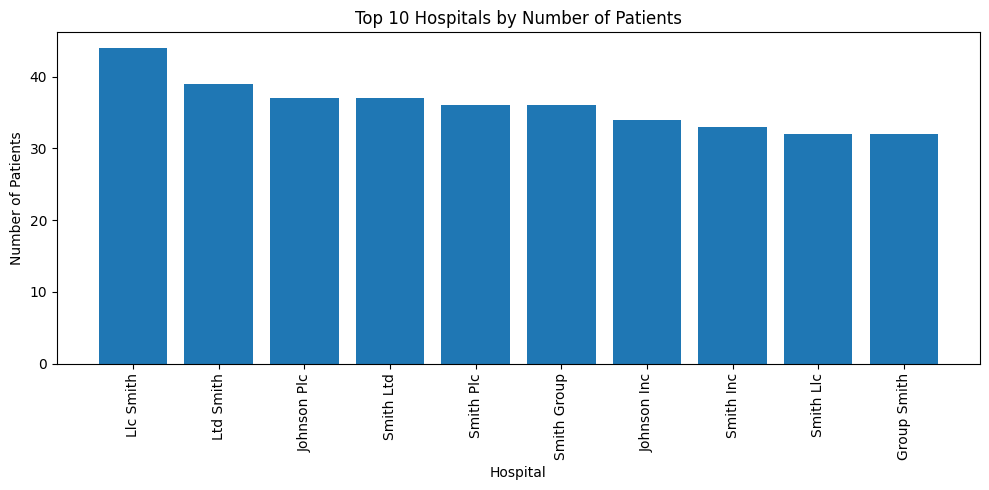

In [52]:
top_hospitals = hospital_summary.sort_values(
    by="total_patients",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_hospitals["hospital"],
    top_hospitals["total_patients"]
)

plt.title("Top 10 Hospitals by Number of Patients")
plt.xlabel("Hospital")
plt.ylabel("Number of Patients")
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

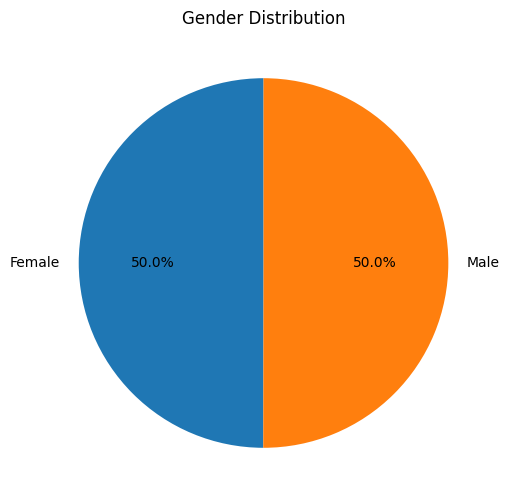

In [53]:
plt.figure(figsize=(6,6))

plt.pie(
    gender_summary["total_patients"],
    labels=gender_summary["gender"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Gender Distribution")

plt.show()

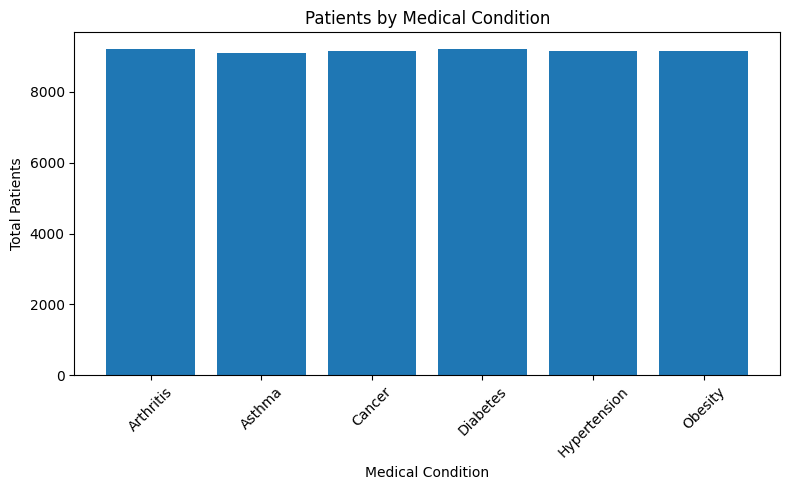

In [54]:
plt.figure(figsize=(8,5))

plt.bar(
    condition_summary["medical_condition"],
    condition_summary["total_patients"]
)

plt.title("Patients by Medical Condition")
plt.xlabel("Medical Condition")
plt.ylabel("Total Patients")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

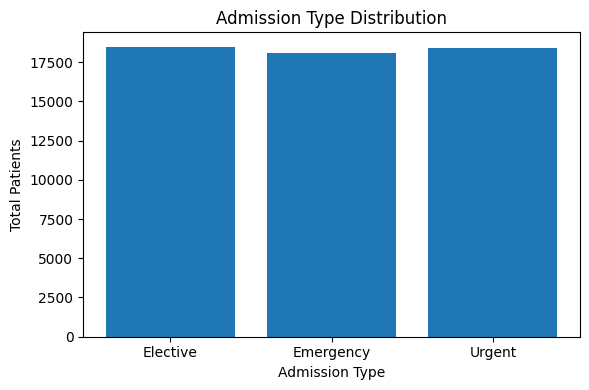

In [55]:
plt.figure(figsize=(6,4))

plt.bar(
    admission_summary["admission_type"],
    admission_summary["total_patients"]
)

plt.title("Admission Type Distribution")
plt.xlabel("Admission Type")
plt.ylabel("Total Patients")

plt.tight_layout()

plt.show()

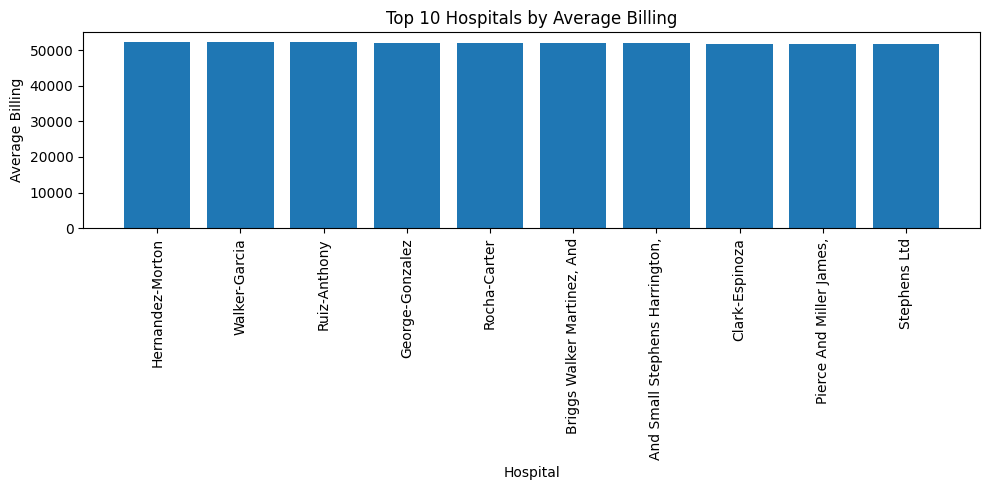

In [56]:
top_billing = billing_summary.sort_values(
    by="average_billing",
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top_billing["hospital"],
    top_billing["average_billing"]
)

plt.title("Top 10 Hospitals by Average Billing")
plt.xlabel("Hospital")
plt.ylabel("Average Billing")

plt.xticks(rotation=90)

plt.tight_layout()

plt.show()

In [57]:
test_result_summary = (
    silver_df.groupby("test_results")
    .size()
    .reset_index(name="total_patients")
)

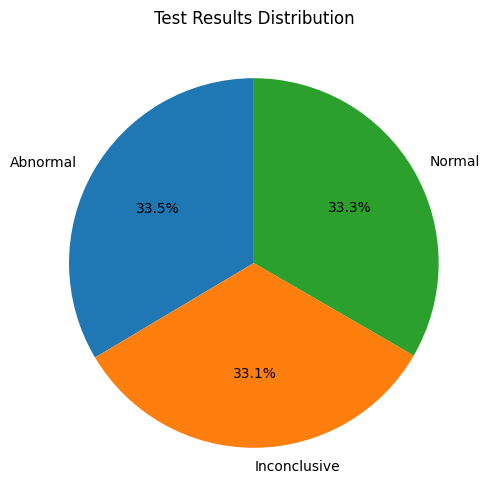

In [58]:
plt.figure(figsize=(6,6))

plt.pie(
    test_result_summary["total_patients"],
    labels=test_result_summary["test_results"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Test Results Distribution")

plt.show()

## Dashboard & Visualization

The dashboard presents important insights from the healthcare dataset using charts. These visualizations help understand patient distribution, hospital performance, billing patterns, admission types, medical conditions, gender distribution, and test results in a simple and effective way.

## Conclusion

This project demonstrates a healthcare data pipeline using the Medallion Architecture. The raw dataset was stored in the Bronze layer, cleaned in the Silver layer, and summarized in the Gold layer. SQL queries and visualizations were used to generate useful business insights from the healthcare data.

## Technologies Used

- Python
- Pandas
- DuckDB
- Matplotlib
- Google Colab

## Future Scope

This project can be further extended using Apache Spark, Delta Lake, and cloud storage platforms for handling larger healthcare datasets.